In [1]:
import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\bhara\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
url = r"D:\fsds\projects\datasets\eda automization using ollama\titanic_ dataset_final.csv"
df = pd.read_csv(url)

In [3]:
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [5]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


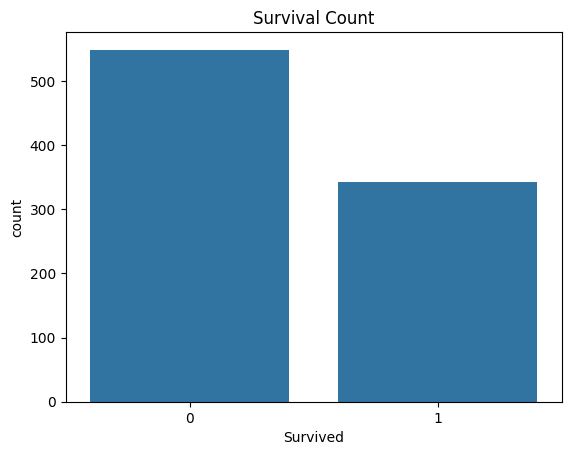

In [6]:
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

In [7]:
import ollama


def generate_insights(df_summary):
    prompt = (
        f"Analyse the following dataset summary and provide insights:\n{df_summary}"
    )
    response = ollama.chat(
        model="gemma", messages=[{"role": "user", "content": prompt}]
    )
    return response["message"]["content"]


summary = df.describe().to_string()
insights = generate_insights(summary)
print("\n * AI Generated Insights:\n", insights)


 * AI Generated Insights:
 ## Insights from Dataset Summary:

**Passenger Demographics:**

* The dataset includes data on 891 passengers.
* Most passengers (89%) survived (Survived = 0.3838).
* The average age of passengers is 29.7 years.
* Most passengers traveled in 3rd class (64%).

**Passenger Characteristics:**

* About half of the passengers had no siblings or parents traveling with them (SibSp and Parch = 0).
* The average fare paid was 32.20.

**Survival Probabilities:**

* The average survival rate for 1st class passengers is 100%, while it is 28% for 3rd class passengers.
* Age appears to have a slight influence on survival, with younger passengers having a slightly higher survival rate (mean age of survivors = 28.0 vs 44.6).

**Fare and Class Influence:**

* Passengers in 1st class paid significantly more than those in 3rd class (median fare: 14.45 vs 7.91).
* There is a correlation between fare and survival, with higher fares associated with a higher probability of surviva

In [8]:
import gradio as gr

def eda_analysis(file):
    df = pd.read_csv(file.name)
    summary = df.describe().to_string()
    insights = generate_insights(summary)
    
    return insights
demo = gr.Interface(fn=eda_analysis, inputs='file', outputs='text', title='AI Powered EDA with Gemma')
demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "c:\Users\bhara\AppData\Local\Programs\Python\Python312\Lib\site-packages\gradio\queueing.py", line 625, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\bhara\AppData\Local\Programs\Python\Python312\Lib\site-packages\gradio\route_utils.py", line 322, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\bhara\AppData\Local\Programs\Python\Python312\Lib\site-packages\gradio\blocks.py", line 2220, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\bhara\AppData\Local\Programs\Python\Python312\Lib\site-packages\gradio\blocks.py", line 1731, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\bhara\AppData\Local\P

In [1]:
import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ollama


# Function to Perform EDA and Generate Visualizations
def eda_analysis(file_path):
    df = pd.read_excel(file_path)

    # Fill missing values with median for numeric columns
    for col in df.select_dtypes(include=["number"]).columns:
        df[col].fillna(df[col].median(), inplace=True)

    # Fill missing values with mode for categorical columns
    for col in df.select_dtypes(include=["object"]).columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

    # Data Summary
    summary = df.describe(include="all").to_string()

    # Missing Values
    missing_values = df.isnull().sum().to_string()

    # Generate AI Insights
    insights = generate_ai_insights(summary)

    # Generate Data Visualizations
    plot_paths = generate_visualizations(df)

    return (
        f"\n Data Loaded Successfully!\n\n Summary:\n{summary}\n\n Missing Values:\n{missing_values}\n\n AI Insights:\n{insights}",
        plot_paths,
    )


# AI-Powered Insights using Mistral-7B (Ollama)
def generate_ai_insights(df_summary):
    prompt = f"Analyze the dataset summary and provide insights:\n\n{df_summary}"
    response = ollama.chat(
        model="mistral", messages=[{"role": "user", "content": prompt}]
    )
    return response["message"]["content"]


# Function to Generate Data Visualizations
def generate_visualizations(df):
    plot_paths = []

    # Histograms for Numeric Columns
    for col in df.select_dtypes(include=["number"]).columns:
        plt.figure(figsize=(6, 4))
        sns.histplot(df[col], bins=30, kde=True, color="blue")
        plt.title(f"Distribution of {col}")
        path = f"{col}_distribution.png"
        plt.savefig(path)
        plot_paths.append(path)
        plt.close()

    # Correlation Heatmap (only numeric columns)
    numeric_df = df.select_dtypes(include=["number"])
    if not numeric_df.empty:
        plt.figure(figsize=(8, 5))
        sns.heatmap(
            numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
        )
        plt.title("Correlation Heatmap")
        path = "correlation_heatmap.png"
        plt.savefig(path)
        plot_paths.append(path)
        plt.close()

    return plot_paths


# Gradio Interface
demo = gr.Interface(
    fn=eda_analysis,
    inputs=gr.File(type="filepath"),
    outputs=[gr.Textbox(label="EDA Report"), gr.Gallery(label="Data Visualizations")],
    title="📊 LLM-Powered Exploratory Data Analysis (EDA)",
    description="Upload any dataset CSV file and get automated EDA insights with AI-powered analysis and visualizations.",
)

# Launch the Gradio App
demo.launch()


c:\Users\bhara\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
